### 데이터 전처리: 변수 변환 코드 예제

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PowerTransformer, LabelEncoder
from sklearn.feature_extraction import FeatureHasher
# 예제 데이터 생성
data = {
    'numerical_col_1': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100],
    'numerical_col_2': [1, 2, 3, 10, 20, 30, 40, 50, 60, 70],
    'categorical_col_1': ['A', 'B', 'A', 'C', 'B', 'A', 'C', 'B', 'A', 'C'],
    'categorical_col_2': ['Red', 'Blue', 'Green', 'Red', 'Blue', 'Green', 'Red', 'Blue', 'Green', 'Red'],
    'text_col': ['apple', 'banana', 'orange', 'grape', 'kiwi', 'mango', 'pear', 'peach', 'plum', 'lemon']
}
df = pd.DataFrame(data)
display(df.head())

,numerical_col_1,numerical_col_2,categorical_col_1,categorical_col_2,text_col
0,10,1,A,Red,apple
1,20,2,B,Blue,banana
2,30,3,A,Green,orange
3,40,10,C,Red,grape
4,50,20,B,Blue,kiwi


#### 1. 수치형 변수 변환
*스케일링 시 train에만 fit을 적용하고 tranform하고 test에는 이미 train으로 적합되었기 때문에 transform만 사용해야함*

##### 1.1 표준화 (Standardization)
*N(0,1)* 을 따르게 스케일링 하는데, 이상치에 매우 민감하므로 이상치 정제 후 사용해야하고, 회귀보다는 분류에 유용함

In [ ]:
scaler = StandardScaler()
df['numerical_col_1_standardized'] = scaler.fit_transform(df[['numerical_col_1']])
display(df[['numerical_col_1', 'numerical_col_1_standardized']].head())

,numerical_col_1,numerical_col_1_standardized
0,10,-1.566699
1,20,-1.218544
2,30,-0.870388
3,40,-0.522233
4,50,-0.174078


##### 1.2 Min-Max Scaling스케일링 (MaxAbsScaling)
*Min-Max* 스케일링은 컬럼을 0~1 사이로 스케일링 하는데 이상치에 매우 민감하므로 이상치 정제하고 해야함. 분류보다는 회귀에 유용

In [ ]:
min_max_scaler = MinMaxScaler()
df['numerical_col_1_minmax_scaled'] = min_max_scaler.fit_transform(df[['numerical_col_1']])
display(df[['numerical_col_1', 'numerical_col_1_minmax_scaled']].head())

#maxabsscaler -1에서 1로 스케일링 / 데이터가 양수면 minmax랑 똑같음
from sklearn.preprocessing import MaxAbsScaler
max_abs_scaler = MaxAbsScaler()
df['numerical_col_1_maxabs_scaled'] = max_abs_scaler.fit_transform(df[['numerical_col_1']])
display(df[['numerical_col_1', 'numerical_col_1_maxabs_scaled']].head())

,numerical_col_1,numerical_col_1_minmax_scaled
0,10,0.000000
1,20,0.111111
2,30,0.222222
3,40,0.333333
4,50,0.444444


,numerical_col_1,numerical_col_1_maxabs_scaled
0,10,0.1
1,20,0.2
2,30,0.3
3,40,0.4
4,50,0.5


##### 1.3 로그 변환 (Log Transformation)

In [ ]:
# 0 또는 음수 값 처리를 위해 log1p (log(1+x)) 사용
df['numerical_col_2_log'] = np.log1p(df['numerical_col_2'])
display(df[['numerical_col_2', 'numerical_col_2_log']].head())

,numerical_col_2,numerical_col_2_log
0,1,0.693147
1,2,1.098612
2,3,1.386294
3,10,2.397895
4,20,3.044522


##### 1.4 거듭제곱 변환 (Power Transformation)
box-cox, yeo-johnson이 있는데, box-cox는 데이터를 정규분포에 가깝게 하거나 분산을 안정화함. 정규성화 시킴. yeo-johnson는 분산을 안정화시키고 음수를 포함하는 실수에 적용 가능

In [ ]:
# Yeo-Johnson 또는 Box-Cox 변환 사용 (데이터에 음수가 있어도 Yeo-Johnson 사용 가능)
power_transformer = PowerTransformer(method='yeo-johnson')
df['numerical_col_2_power_transformed'] = power_transformer.fit_transform(df[['numerical_col_2']])
display(df[['numerical_col_2', 'numerical_col_2_power_transformed']].head())

,numerical_col_2,numerical_col_2_power_transformed
0,1,-1.480920
1,2,-1.297051
2,3,-1.151481
3,10,-0.519970
4,20,0.003817


##### 1.5 순위로 변환 (Rank Transformation)

In [ ]:
# default: average
df['numerical_col_1_rank'] = df['numerical_col_1'].rank()
# method='dense': 동일한 값에 대해 같은 순위를 부여하고, 다음 순위는 연속된 값으로 부여
df['numerical_col_1_dense_rank'] = df['numerical_col_1'].rank(method='dense')
display(df[['numerical_col_1', 'numerical_col_1_rank', 'numerical_col_1_dense_rank']].head())

,numerical_col_1,numerical_col_1_rank,numerical_col_1_dense_rank
0,10,1.0,1.0
1,20,2.0,2.0
2,30,3.0,3.0
3,40,4.0,4.0
4,50,5.0,5.0


##### 1.6 구간 분할 (Binning / Discretization)

##### 1.7 Robust 스케일링 (Robust Scaling)
평균과 분산대신 중앙값과 사분위값을 사용. 중앙값을 0으로 설정하고 IQR을 이용하여 이상치 영향 최소화



,numerical_col_1,numerical_col_1_robust_scaled
0,10,-1.000000
1,20,-0.777778
2,30,-0.555556
3,40,-0.333333
4,50,-0.111111


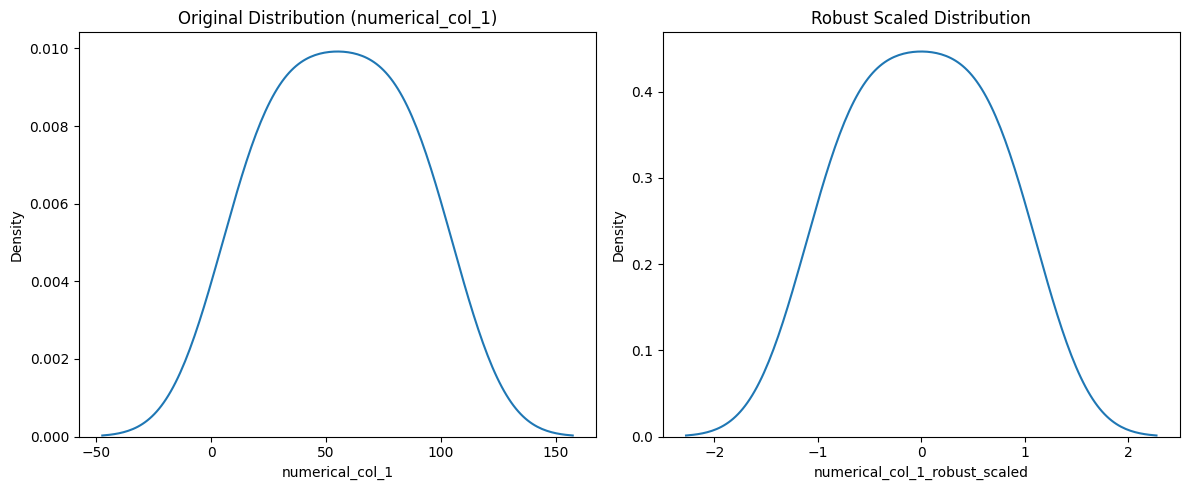

In [ ]:
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt
import seaborn as sns

robust_scaler = RobustScaler()
#quantile_range= 로 범위 설정. default [0.25, 0.75]
df['numerical_col_1_robust_scaled'] = robust_scaler.fit_transform(df[['numerical_col_1']])

display(df[['numerical_col_1', 'numerical_col_1_robust_scaled']].head())

# 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.kdeplot(df['numerical_col_1'], ax=axes[0])
axes[0].set_title('Original Distribution (numerical_col_1)')

sns.kdeplot(df['numerical_col_1_robust_scaled'], ax=axes[1])
axes[1].set_title('Robust Scaled Distribution')

plt.tight_layout()
plt.show()

##### 1.8 Quantile Uniform 변환 (Quantile Uniform Transformation)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_data.py:2829: UserWarning: n_quantiles (1000) is greater than the total number of samples (10). n_quantiles is set to n_samples.
  warnings.warn(


,numerical_col_1,numerical_col_1_quantile_uniform
0,10,0.000000
1,20,0.111111
2,30,0.222222
3,40,0.333333
4,50,0.444444


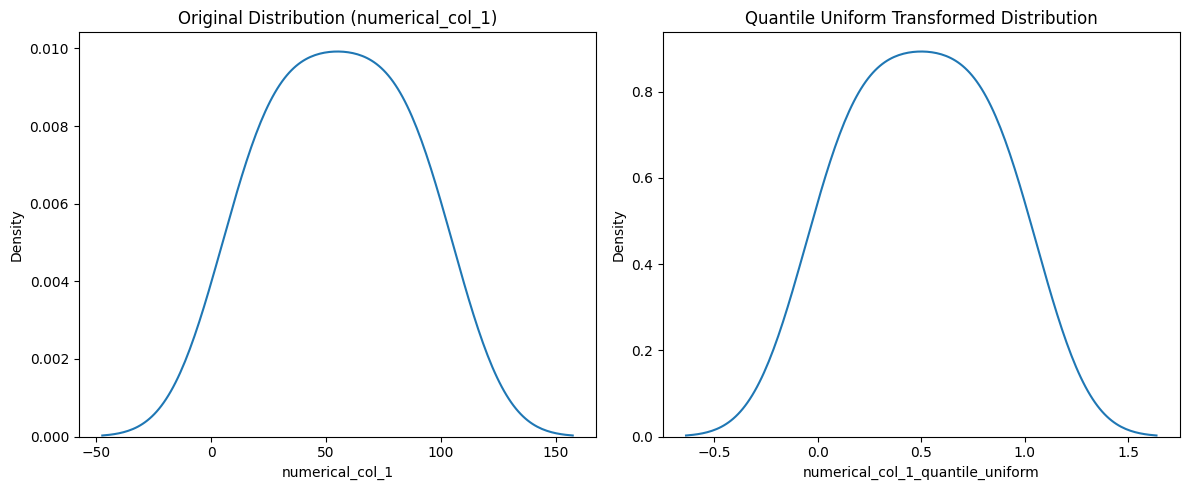

In [ ]:
from sklearn.preprocessing import QuantileTransformer

quantile_uniform_transformer = QuantileTransformer(output_distribution='uniform', random_state=42)
df['numerical_col_1_quantile_uniform'] = quantile_uniform_transformer.fit_transform(df[['numerical_col_1']])

display(df[['numerical_col_1', 'numerical_col_1_quantile_uniform']].head())

# 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.kdeplot(df['numerical_col_1'], ax=axes[0])
axes[0].set_title('Original Distribution (numerical_col_1)')

sns.kdeplot(df['numerical_col_1_quantile_uniform'], ax=axes[1])
axes[1].set_title('Quantile Uniform Transformed Distribution')

plt.tight_layout()
plt.show()

##### 1.9 Quantile Normal 변환 (Quantile Normal Transformation)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_data.py:2829: UserWarning: n_quantiles (1000) is greater than the total number of samples (10). n_quantiles is set to n_samples.
  warnings.warn(


,numerical_col_1,numerical_col_1_quantile_normal
0,10,-5.199338
1,20,-1.220640
2,30,-0.764710
3,40,-0.430727
4,50,-0.139710


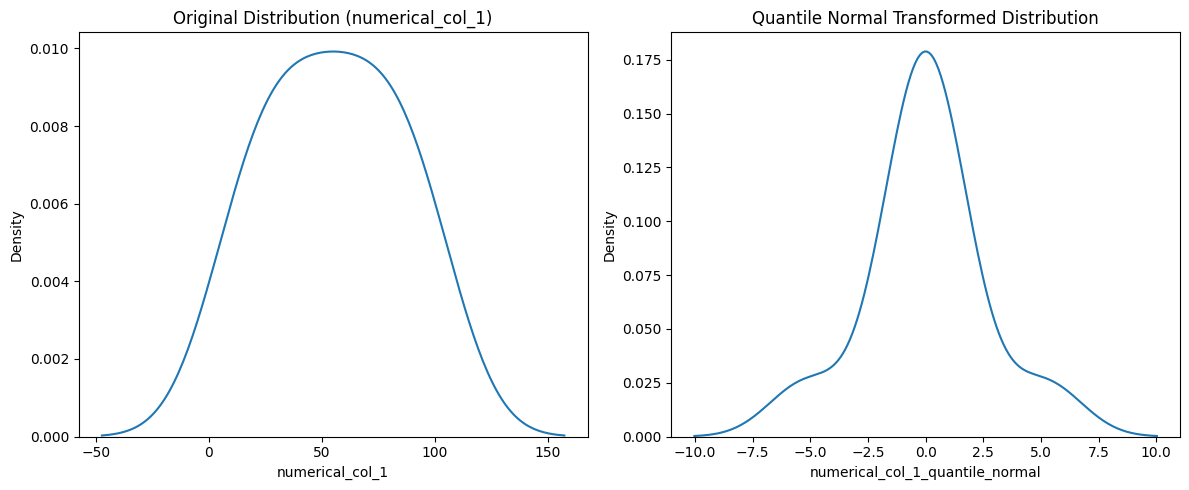

In [ ]:
quantile_normal_transformer = QuantileTransformer(output_distribution='normal', random_state=42)
df['numerical_col_1_quantile_normal'] = quantile_normal_transformer.fit_transform(df[['numerical_col_1']])

display(df[['numerical_col_1', 'numerical_col_1_quantile_normal']].head())

# 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.kdeplot(df['numerical_col_1'], ax=axes[0])
axes[0].set_title('Original Distribution (numerical_col_1)')

sns.kdeplot(df['numerical_col_1_quantile_normal'], ax=axes[1])
axes[1].set_title('Quantile Normal Transformed Distribution')

plt.tight_layout()
plt.show()

##### 1.10. 수치형 구간 분할
```pd.cut``` : 구간의 길이 똑같음  
```pd.qcut``` : 구간 내 데이터 수 똑같음

In [ ]:
# 구간 길이 동일
df['numerical_col_1_binned_width'] = pd.cut(df['numerical_col_1'], bins=3, labels=['Low', 'Medium', 'High'])

# 구간 내 데이터 수 동일 (quantile 기반)
df['numerical_col_1_binned_freq'] = pd.qcut(df['numerical_col_1'], q=3, labels=['Low', 'Medium', 'High'], duplicates='drop')
display(df[['numerical_col_1', 'numerical_col_1_binned_width', 'numerical_col_1_binned_freq']].head())

,numerical_col_1,numerical_col_1_binned_width,numerical_col_1_binned_freq
0,10,Low,Low
1,20,Low,Low
2,30,Low,Low
3,40,Low,Medium
4,50,Medium,Medium


#### 2. 범주형 변수 변환


##### 2.1 원-핫 인코딩 (One-Hot Encoding)

In [ ]:
df_one_hot = pd.get_dummies(df, columns=['categorical_col_1'], prefix='cat1')
#display(df_one_hot.head())
#get_dummies 써도 drop_first = True가 아니면 원핫인코딩
#prefix: 인코딩 컬럼명 접두사

from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder() #sparse_output=False, drop='first'
df_one_hot2 = pd.DataFrame(ohe.fit_transform(df[['categorical_col_1']]).toarray(), \
                           columns=ohe.get_feature_names_out())
display(df_one_hot2)

,categorical_col_1_A,categorical_col_1_B,categorical_col_1_C
0,1.0,0.0,0.0
1,0.0,1.0,0.0
2,1.0,0.0,0.0
3,0.0,0.0,1.0
4,0.0,1.0,0.0
5,1.0,0.0,0.0
6,0.0,0.0,1.0
7,0.0,1.0,0.0
8,1.0,0.0,0.0
9,0.0,0.0,1.0


##### 2.2 더미 코딩 (Dummy Coding)

In [ ]:
# drop_first=True를 사용하여 첫 번째 카테고리를 기준으로 더미 변수 생성 (다중 공선성 방지)
df_dummy = pd.get_dummies(df, columns=['categorical_col_1'], prefix='cat1', drop_first=True)
display(df_dummy.head())

,numerical_col_1,numerical_col_2,categorical_col_2,text_col,numerical_col_1_standardized,numerical_col_1_minmax_scaled,numerical_col_2_log,numerical_col_2_power_transformed,numerical_col_1_rank,numerical_col_1_dense_rank,numerical_col_1_robust_scaled,numerical_col_1_quantile_uniform,numerical_col_1_quantile_normal,numerical_col_1_binned_width,numerical_col_1_binned_freq,cat1_B,cat1_C
0,10,1,Red,apple,-1.566699,0.000000,0.693147,-1.480920,1.0,1.0,-1.000000,0.000000,-5.199338,Low,Low,False,False
1,20,2,Blue,banana,-1.218544,0.111111,1.098612,-1.297051,2.0,2.0,-0.777778,0.111111,-1.220640,Low,Low,True,False
2,30,3,Green,orange,-0.870388,0.222222,1.386294,-1.151481,3.0,3.0,-0.555556,0.222222,-0.764710,Low,Low,False,False
3,40,10,Red,grape,-0.522233,0.333333,2.397895,-0.519970,4.0,4.0,-0.333333,0.333333,-0.430727,Low,Medium,False,True
4,50,20,Blue,kiwi,-0.174078,0.444444,3.044522,0.003817,5.0,5.0,-0.111111,0.444444,-0.139710,Medium,Medium,True,False


##### 2.3 레이블 인코딩 (Label Encoding)

In [ ]:
label_encoder = LabelEncoder()
df['categorical_col_2_encoded'] = label_encoder.fit_transform(df['categorical_col_2'])
display(df[['categorical_col_2', 'categorical_col_2_encoded']].head())

,categorical_col_2,categorical_col_2_encoded
0,Red,2
1,Blue,0
2,Green,1
3,Red,2
4,Blue,0


##### 2.4 특징 해싱 (Feature Hashing)

In [ ]:
# HashingVectorizer를 사용하여 텍스트 데이터를 해싱
# text_col은 단어별로 해싱하므로, Series를 list로 변환하여 입력
# 1. 파라미터 수정 (지원하지 않는 binary, norm 제거)
hashing_vectorizer = FeatureHasher(n_features=5, input_type='string')

# 2. 데이터 변환
# 범주형 변수일 경우 리스트의 리스트 형태로 전달하는 것이 일반적입니다.
data_list = df['text_col'].astype(str).values.reshape(-1, 1).tolist()
hashed_features = hashing_vectorizer.fit_transform(data_list).toarray()

# 결과 확인
import pandas as pd
hashed_df = pd.DataFrame(hashed_features, columns=[f'hash_{i}' for i in range(5)])
print(hashed_df)

   hash_0  hash_1  hash_2  hash_3  hash_4
0     1.0     0.0     0.0     0.0     0.0
1    -1.0     0.0     0.0     0.0     0.0
2    -1.0     0.0     0.0     0.0     0.0
3     0.0     0.0    -1.0     0.0     0.0
4     0.0     0.0     0.0    -1.0     0.0
5     0.0     1.0     0.0     0.0     0.0
6     0.0    -1.0     0.0     0.0     0.0
7     0.0     0.0     0.0    -1.0     0.0
8     0.0     1.0     0.0     0.0     0.0
9    -1.0     0.0     0.0     0.0     0.0


##### 2.5 빈도 인코딩 (Frequency Encoding)

In [ ]:
frequency_map = df['categorical_col_1'].value_counts(normalize=True)
df['categorical_col_1_freq_encoded'] = df['categorical_col_1'].map(frequency_map)
display(df[['categorical_col_1', 'categorical_col_1_freq_encoded']].head())

,categorical_col_1,categorical_col_1_freq_encoded
0,A,0.4
1,B,0.3
2,A,0.4
3,C,0.3
4,B,0.3


#### 3. 모델 성능 비교

##### 3.1. Scaler 별 분류 성능 평가

In [97]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

scalers = [StandardScaler(), MinMaxScaler(), RobustScaler()]
for s in scalers:
    X_train_s = s.fit_transform(X_train)
    model = LogisticRegression().fit(X_train_s, y_train)
    # 테스트 데이터도 같은 스케일러로 변환해서 점수 확인
    score = model.score(s.transform(X_test), y_test)
    print(f"{type(s).__name__} 정확도: {score:.4f}")

StandardScaler 정확도: 0.9386
MinMaxScaler 정확도: 0.9561
RobustScaler 정확도: 0.9386


##### 3.2. Scaler 별 데이터 분포(KDE)

/tmp/ipykernel_14558/1140803441.py:14: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(scaler_list, shade=True)


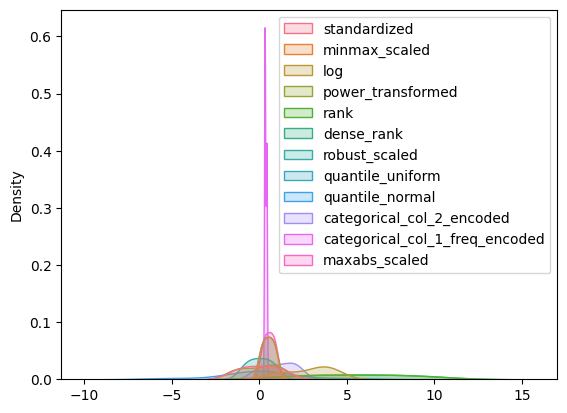

In [98]:
col_list = df.columns
scaler_list = df.iloc[:,5:].copy()

'''scaler_list = df.iloc[:, 5:]로 슬라이싱을 하면 scaler_list는
원본 데이터프레임의 뷰(View)이거나
설정에 따라 복사본일 수 있음.
컬럼명을 바꿀 때 SettingWithCopyWarning 경고가 뜰 수 있으니,
확실하게 .copy()를 붙여주는 것이 안전'''

scaler_list.columns = scaler_list.columns.str.replace('numerical_col_1_','')
scaler_list.columns = scaler_list.columns.str.replace('numerical_col_2_','')
#scaler_list.columns = scaler_list.columns.str.replace(r'^.*_col_\d+_', '', regex=True)

sns.kdeplot(scaler_list, shade=True)
plt.show()



##### 3.3. Scaler 별 성능 및 계수 비교(로지스틱)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_data.py:2829: UserWarning: n_quantiles (1000) is greater than the total number of samples (455). n_quantiles is set to n_samples.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_data.py:2829: UserWarning: n_quantiles (1000) is greater than the total number of samples (455). n_quantiles is set to n_samples.
  warnings.warn(


### 스케일링별 분류 성능 비교 ###
             Scaler  Accuracy  F1_Score
0              None  0.929825  0.942857
1          Standard  0.938596  0.951049
2            MinMax  0.956140  0.965986
3            Robust  0.938596  0.951049
4  Quantile_Uniform  0.964912  0.971429
5   Quantile_Normal  0.938596  0.948905


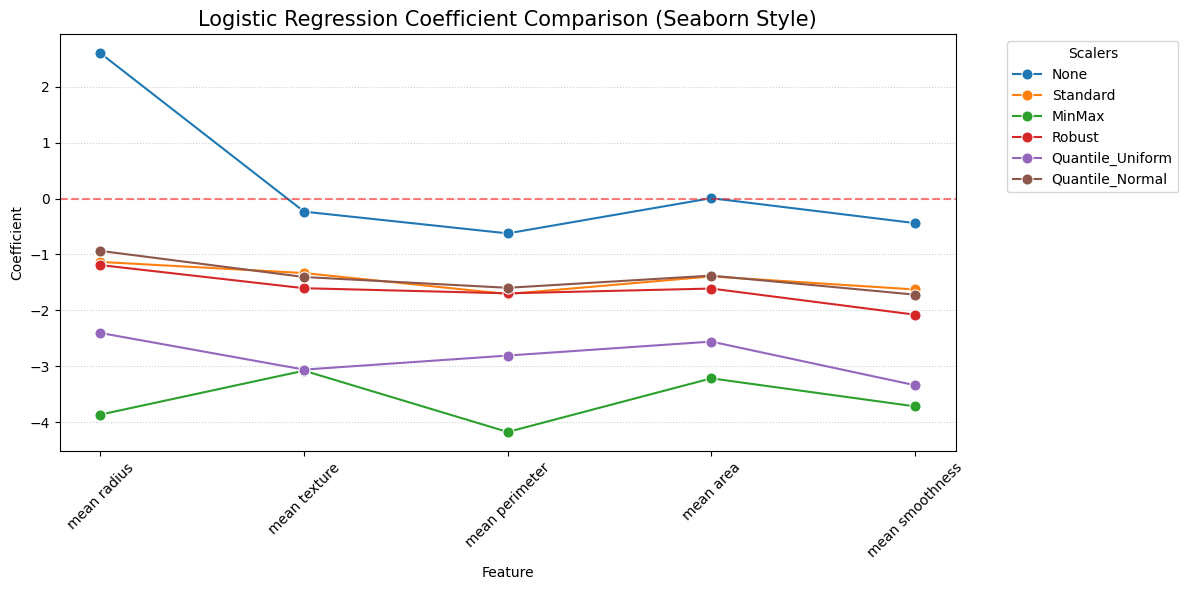

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, QuantileTransformer
from sklearn.metrics import accuracy_score, f1_score

# 1. 데이터 준비 (예시 데이터)
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names).iloc[:, :5] # 시각화를 위해 5개 변수만 사용
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. 스케일러 정의
scalers = {
    "None": None,
    "Standard": StandardScaler(),
    "MinMax": MinMaxScaler(),
    "Robust": RobustScaler(),
    "Quantile_Uniform": QuantileTransformer(output_distribution='uniform', random_state=42),
    "Quantile_Normal": QuantileTransformer(output_distribution='normal', random_state=42)
}

results = []
coef_list = []

# 3. 루프를 통한 학습 및 평가
for name, scaler in scalers.items():
    # 스케일링 적용
    if scaler:
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
    else:
        X_train_scaled, X_test_scaled = X_train, X_test

    # 모델 학습 (로지스틱 회귀)
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_scaled, y_train)

    # 예측 및 성능 평가
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({'Scaler': name, 'Accuracy': acc, 'F1_Score': f1})

    # 회귀계수 저장 (첫 번째 클래스 기준)
    coef_df = pd.DataFrame({
        'Feature': X.columns,
        'Coefficient': model.coef_[0],
        'Scaler': name
    })
    coef_list.append(coef_df)

# 결과 데이터프레임 구성
df_results = pd.DataFrame(results)
df_coefs = pd.concat(coef_list)

# 4. 성능 지표 출력
print("### 스케일링별 분류 성능 비교 ###")
print(df_results)

plt.figure(figsize=(12, 6))

# 데이터 구조 변경 없이 그대로 사용 (Long-form 데이터 활용)
# x축을 Feature, y축을 Coefficient로 두고, Scaler별로 선(hue)을 그립니다.
sns.lineplot(data=df_coefs, x='Feature', y='Coefficient', hue='Scaler', marker='o', markersize=8)

# 시각적 가이드 추가
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.title("Logistic Regression Coefficient Comparison (Seaborn Style)", fontsize=15)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle=':', alpha=0.6)

# 범례 위치 조정
plt.legend(title="Scalers", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()